In [ ]:
!pip install -q transformers datasets accelerate pandas scikit-learn evaluate rouge_score nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
import evaluate
import nltk
from nltk.translate.meteor_score import meteor_score

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)

from datasets import Dataset
from sklearn.model_selection import train_test_split
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import torch
import pandas as pd
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = torch.device("cuda")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [ ]:
csv_path = "/content/drive/MyDrive/BTP/combined.csv"
df = pd.read_csv(csv_path)

print("Total rows:", len(df))
print("Columns:", list(df.columns))

PROMPT = "Rewrite the sentence into gender-inclusive language without changing the meaning: "
df["input_text"] = PROMPT + df["non-inclusive"]
df["target_text"] = df["inclusive"]

train_df, temp_df = train_test_split(df[["input_text", "target_text"]], test_size=0.3, random_state=50)
val_df, test_df   = train_test_split(temp_df, test_size=1/3, random_state=42)
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
df.head()

Total rows: 1677
Columns: ['non-inclusive', 'inclusive']
Train size: 1173
Validation size: 336
Test size: 168


,non-inclusive,inclusive,input_text,target_text
0,The ballboy rushed to collect the stray balls ...,The ball person rushed to collect the stray b...,Rewrite the sentence into gender-inclusive lan...,The ball person rushed to collect the stray b...
1,The ballboys stood alert at the edges of the t...,The ball people stood alert at the edges of t...,Rewrite the sentence into gender-inclusive lan...,The ball people stood alert at the edges of t...
2,The batboy carried extra bats to the dugout.,The bat person carried extra bats to the dugout.,Rewrite the sentence into gender-inclusive lan...,The bat person carried extra bats to the dugout.
3,The batboys prepared the equipment before the ...,The bat people prepared the equipment before ...,Rewrite the sentence into gender-inclusive lan...,The bat people prepared the equipment before ...
4,The bellboy helped us with our luggage at the ...,The bellhop helped us with our luggage at the...,Rewrite the sentence into gender-inclusive lan...,The bellhop helped us with our luggage at the...


In [ ]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))
train_ds[0], test_ds[0], val_ds[0]

({'input_text': 'Rewrite the sentence into gender-inclusive language without changing the meaning: A teacher must be nurturing; she helps students grow.',
  'target_text': 'A teacher must be supportive; they help students grow.'},
 {'input_text': 'Rewrite the sentence into gender-inclusive language without changing the meaning: Her work as a poetess has inspired many young girls.',
  'target_text': 'Her work as a poet has inspired many young writers.'},
 {'input_text': 'Rewrite the sentence into gender-inclusive language without changing the meaning: The community honored the brave policewomen for their service.',
  'target_text': 'The community honored the brave police officers for their service.'})

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["input_text"],
        text_target=example["target_text"],
        padding=True,
        truncation=True
    )
train_tok = train_ds.map(tokenize_function,batched=False, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_function,batched=False, remove_columns=val_ds.column_names)
test_tok  = test_ds.map(tokenize_function,batched=False, remove_columns=test_ds.column_names)
train_tok[0]# STEP 6: Data collator and training arguments (safe config)

Map:   0%|          | 0/1173 [00:00<?, ? examples/s]

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

{'input_ids': [419,
  17504,
  8,
  7142,
  139,
  7285,
  18,
  23099,
  15,
  1612,
  406,
  2839,
  8,
  2530,
  10,
  71,
  3145,
  398,
  36,
  27089,
  117,
  255,
  1691,
  481,
  1604,
  5,
  1],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'labels': [71, 3145, 398, 36, 12758, 117, 79, 199, 481, 1604, 5, 1]}

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/model_2",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=50,
    learning_rate=2e-4,

    logging_steps=100,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="no",
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

print("TrainingArguments configured correctly")

TrainingArguments configured correctly


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer created")
trainer.train()

Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Trainer created


Step,Training Loss,Validation Loss
100,7.482766,5.708355
200,5.961582,4.746874
300,5.075672,4.048525
400,4.284618,3.473133
500,3.714121,3.032219
600,3.264395,2.704122
700,2.836153,2.423932
800,2.574650,2.212687
900,2.331000,2.049106
1000,2.066188,1.892917


TrainOutput(global_step=3800, training_loss=1.610959502772281, metrics={'train_runtime': 907.8345, 'train_samples_per_second': 64.604, 'train_steps_per_second': 16.192, 'total_flos': 622175612617728.0, 'train_loss': 1.610959502772281, 'epoch': 12.92517006802721})

In [ ]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval_loss:", trainer.state.best_metric)

Best checkpoint: None
Best eval_loss: 0.8691326975822449


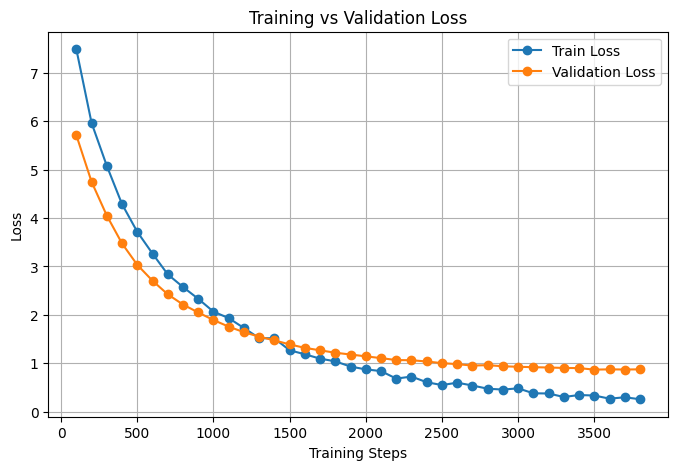

In [ ]:
log_history = trainer.state.log_history

train_steps = []
train_losses = []

val_steps = []
val_losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])

    if "eval_loss" in entry and "step" in entry:
        val_steps.append(entry["step"])
        val_losses.append(entry["eval_loss"])
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
plt.plot(val_steps, val_losses, label="Validation Loss", marker="o")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



###Genrating o/p on the temporary test data made by splitting the training set.

In [ ]:
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_df_reset = test_df.reset_index(drop=True)

predictions = []
references  = []

results = []
for idx, row in test_df_reset.iterrows():
    pred = generate_output(row["input_text"])
    ref  = row["target_text"]

    predictions.append(pred.strip())
    references.append(ref.strip())

    results.append({
        "id": idx,
        "input": row["input_text"].replace(PROMPT, ""),
        "result": pred,
        "labelled": ref
    })

output_df = pd.DataFrame(results)
output_path = "/content/drive/MyDrive/BTP/Outputs/comb_results2.csv"
output_df.to_csv(output_path, index=False)
print("Test file saved at:", output_path)

Test file saved at: /content/drive/MyDrive/BTP/Outputs/comb_results2.csv


###Genrating o/p on the final test data.

In [ ]:
import pandas as pd
import torch

model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

input_path = "/content/drive/MyDrive/BTP/Testing_english_pairs.csv"
df = pd.read_csv(input_path)

predictions = []

for _, row in df.iterrows():
    prompt = row["Input Prompt"]
    pred = generate_output(prompt)
    predictions.append(pred.strip())

output_df = pd.DataFrame({
    "predictions": predictions
})

output_path = "/content/drive/MyDrive/BTP/Outputs/predictions_2.csv"
output_df.to_csv(output_path, index=False)

print("Output file saved at:", output_path)


Output file saved at: /content/drive/MyDrive/BTP/Outputs/predictions_2.csv
